# Fairness and Subgroup Analysis

Checkpoint 44 audits the selected sigmoid-calibrated Logistic Regression across available employee groups. It uses only the 2024 validation period, keeps the 2025 test target locked, and does not assign a binary fair/unfair verdict.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED = PROJECT_ROOT / 'data' / 'processed'

groups = pd.read_csv(PROCESSED / 'retention_fairness_group_metrics.csv')
disparities = pd.read_csv(PROCESSED / 'retention_fairness_disparities.csv')
comparison = pd.read_csv(PROCESSED / 'retention_fairness_model_comparison.csv')
checks = pd.read_csv(PROCESSED / 'retention_fairness_validation.csv')

selected = groups.loc[groups['model_variant'].eq('Selected model')].copy()
eligible = selected.loc[selected['eligible_for_disparity_comparison'].eq(True)].copy()

## Overall sensitivity comparison

The second model removes age and education only as a diagnostic sensitivity check. It does not replace the selected model.

In [2]:
comparison[[
    'model_variant',
    'brier_score',
    'pr_auc',
    'roc_auc',
    'top_fraction_precision',
    'top_fraction_capture',
    'captured_positive_cases',
    'selected_for_use',
]].round(4)

,model_variant,brier_score,pr_auc,roc_auc,top_fraction_precision,top_fraction_capture,captured_positive_cases,selected_for_use
0,Selected model,0.0932,0.1638,0.6211,0.1971,0.1860,109,True
1,Age and education excluded,0.0931,0.1668,0.6200,0.2007,0.1894,111,False


## Selected-model subgroup metrics

Selection rate measures how often a group enters the global top 10%. Recall measures how many known attrition cases are captured. The calibration gap is mean predicted probability minus observed attrition.

In [3]:
selected[[
    'attribute',
    'group',
    'sample_size',
    'positive_cases',
    'selection_rate',
    'true_positive_rate',
    'false_positive_rate',
    'precision',
    'calibration_gap',
    'eligible_for_disparity_comparison',
]].round(4)

,attribute,group,sample_size,positive_cases,selection_rate,true_positive_rate,false_positive_rate,precision,calibration_gap,eligible_for_disparity_comparison
0,age_band,Under 30,1139,129,0.1203,0.2016,0.1099,0.1898,-0.0102,True
1,age_band,40-49,1405,156,0.0996,0.1346,0.0953,0.1500,-0.0112,True
2,age_band,30-39,1363,135,0.0902,0.2074,0.0774,0.2276,0.0004,True
3,age_band,50-59,1279,133,0.0915,0.2030,0.0785,0.2308,-0.0057,True
4,age_band,60+,335,33,0.1075,0.2121,0.0960,0.1944,0.0036,True
5,education_level,Bachelor's,2593,286,0.1103,0.1713,0.1027,0.1713,-0.0082,True
6,education_level,Master's,1256,123,0.1035,0.2195,0.0909,0.2077,0.0048,True
7,education_level,Doctorate,176,11,0.0057,0.0000,0.0061,0.0000,0.0128,False
8,education_level,Associate,807,75,0.1053,0.1867,0.0970,0.1647,0.0086,True
9,education_level,High School,689,91,0.0740,0.2088,0.0535,0.3725,-0.0390,True


## Descriptive disparity summary

These are max-minus-min gaps across groups with sufficient validation evidence. Screening flags request review; they are not legal thresholds or proof of discrimination.

In [4]:
disparities[[
    'model_variant',
    'attribute',
    'eligible_groups',
    'demographic_parity_difference',
    'equal_opportunity_difference',
    'false_positive_rate_difference',
    'maximum_absolute_calibration_gap',
    'screening_review_flag',
    'review_triggers',
]].round(4)

,model_variant,attribute,eligible_groups,demographic_parity_difference,equal_opportunity_difference,false_positive_rate_difference,maximum_absolute_calibration_gap,screening_review_flag,review_triggers
0,Selected model,age_band,5,0.0300,0.0775,0.0325,0.0112,False,NaN
1,Selected model,education_level,4,0.0363,0.0482,0.0492,0.0390,False,NaN
2,Selected model,region,4,0.1561,0.2630,0.1418,0.0193,True,"demographic_parity, equal_opportunity, false_p..."
3,Selected model,employment_type,2,0.1957,0.2809,0.1810,0.0064,True,"demographic_parity, equal_opportunity, false_p..."
4,Selected model,department_name,8,0.4340,0.5419,0.4157,0.0281,True,"demographic_parity, equal_opportunity, false_p..."
5,Selected model,job_level,3,0.2238,0.3526,0.2049,0.0185,True,"demographic_parity, equal_opportunity, false_p..."
6,Selected model,organizational_level,2,0.0800,0.1774,0.0680,0.0354,True,equal_opportunity
7,Age and education excluded,age_band,5,0.0402,0.1428,0.0310,0.0116,True,equal_opportunity
8,Age and education excluded,education_level,4,0.0638,0.1573,0.0661,0.0273,True,equal_opportunity
9,Age and education excluded,region,4,0.1327,0.2422,0.1183,0.0192,True,"demographic_parity, equal_opportunity, false_p..."


## Selection-rate visualization

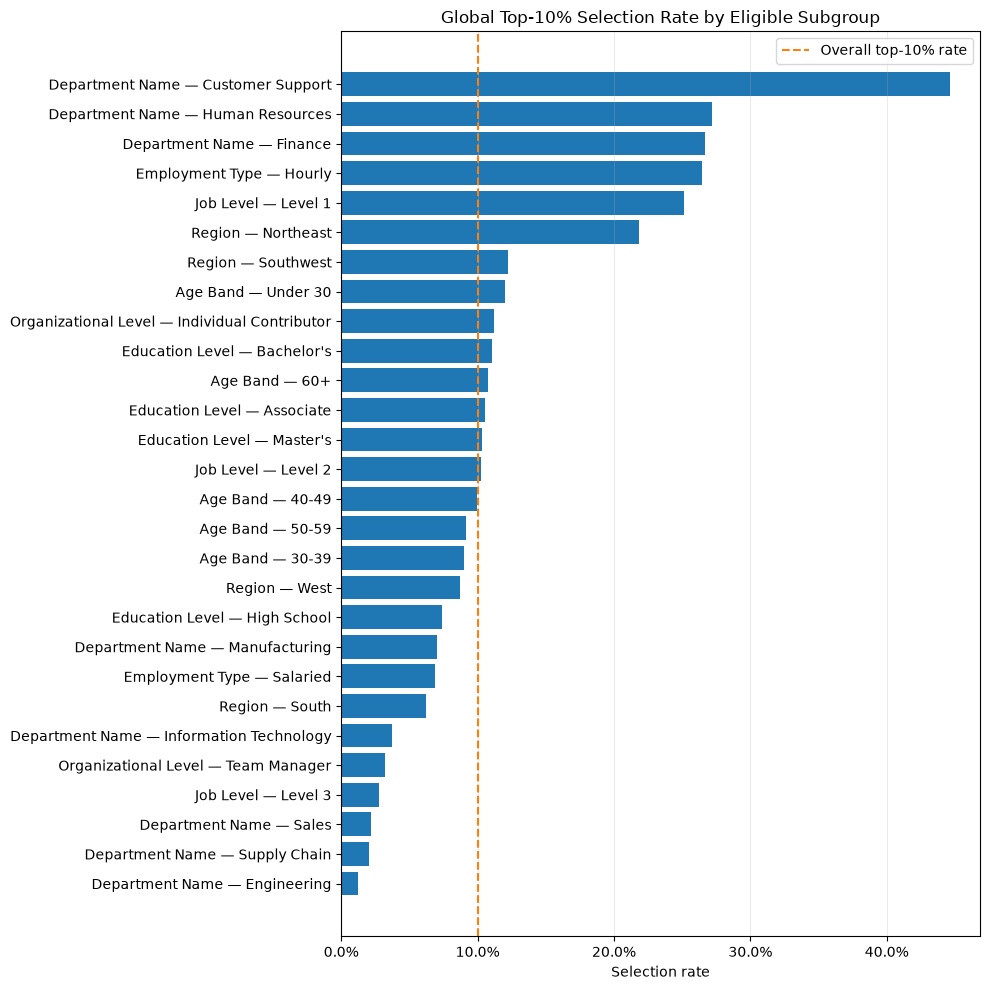

In [5]:
plotted = eligible.sort_values('selection_rate')
figure, axis = plt.subplots(figsize=(10, 10))
axis.barh(plotted['group_label'], plotted['selection_rate'])
axis.axvline(0.10, color='tab:orange', linestyle='--', label='Overall top-10% rate')
axis.set(xlabel='Selection rate', title='Global Top-10% Selection Rate by Eligible Subgroup')
axis.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axis.legend()
axis.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Recall visualization

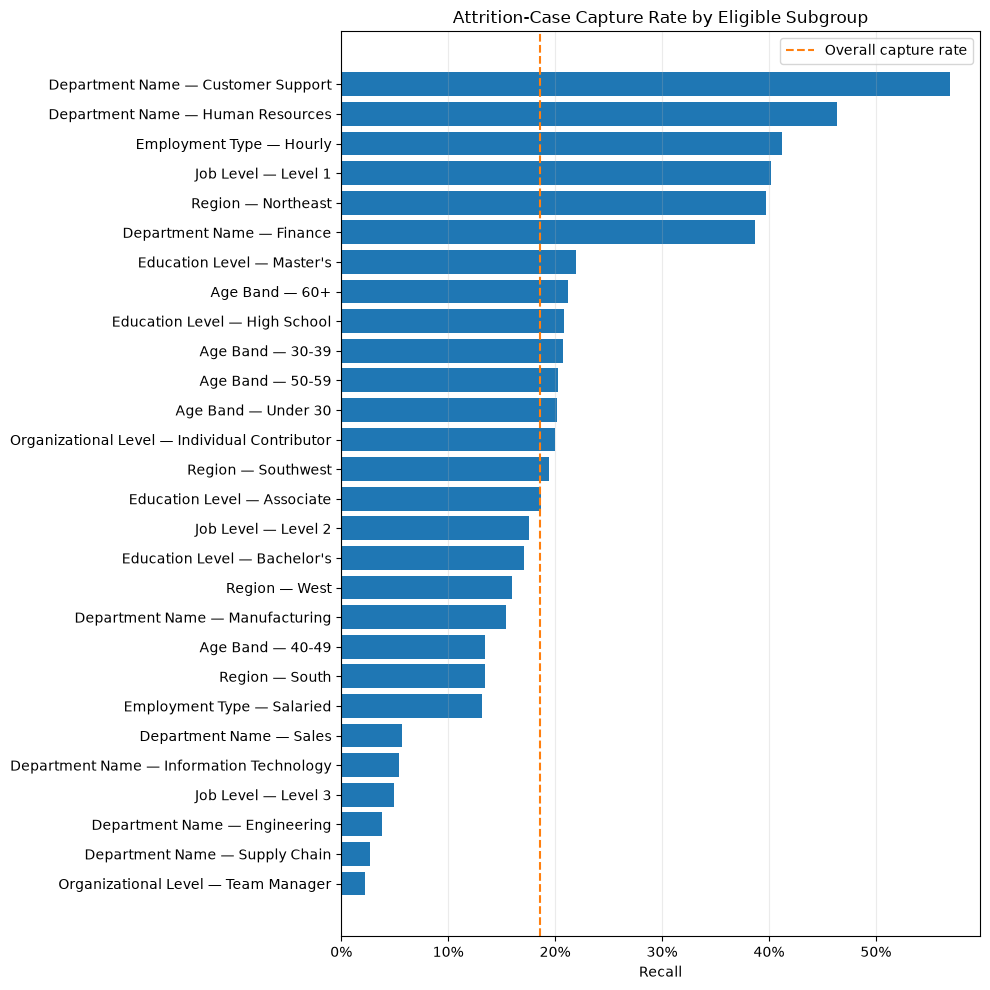

In [6]:
plotted = eligible.sort_values('true_positive_rate')
overall_capture = float(comparison.loc[comparison['selected_for_use'].eq(True), 'top_fraction_capture'].iloc[0])
figure, axis = plt.subplots(figsize=(10, 10))
axis.barh(plotted['group_label'], plotted['true_positive_rate'])
axis.axvline(overall_capture, color='tab:orange', linestyle='--', label='Overall capture rate')
axis.set(xlabel='Recall', title='Attrition-Case Capture Rate by Eligible Subgroup')
axis.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axis.legend()
axis.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Calibration visualization

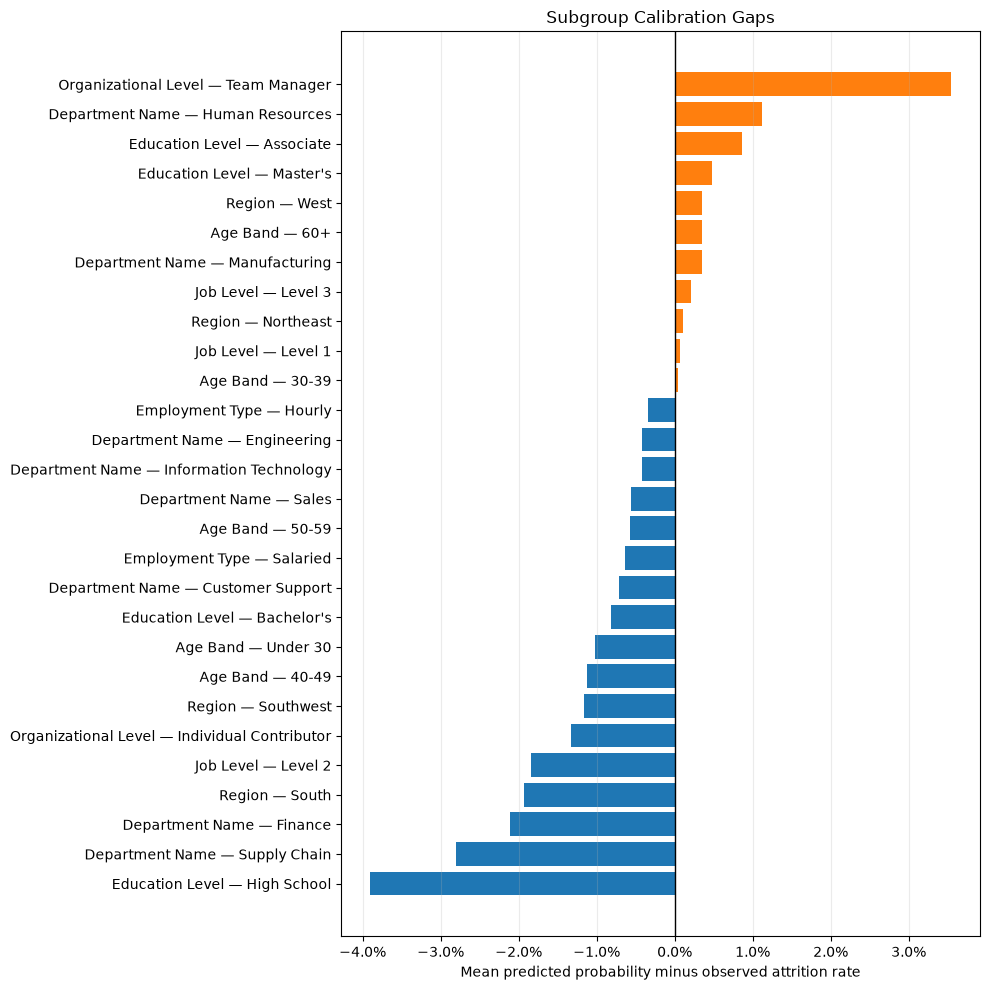

In [7]:
plotted = eligible.sort_values('calibration_gap')
colors = plotted['calibration_gap'].ge(0).map({True: 'tab:orange', False: 'tab:blue'})
figure, axis = plt.subplots(figsize=(10, 10))
axis.barh(plotted['group_label'], plotted['calibration_gap'], color=colors)
axis.axvline(0, color='black', linewidth=1)
axis.set(
    xlabel='Mean predicted probability minus observed attrition rate',
    title='Subgroup Calibration Gaps',
)
axis.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axis.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Validation and interpretation

All checks must pass. Large gaps identify areas for investigation, not a fair/unfair verdict. The records are synthetic, missing protected attributes cannot be evaluated, and removing direct fields cannot remove all proxy information.

In [8]:
checks[['check', 'status', 'observed', 'requirement']]

,check,status,observed,requirement
0,Configured calibration method remains selected,PASS,Sigmoid,Sigmoid
1,Selected scores remain probability-display ready,PASS,True,True
2,Reserved test target remains unused,PASS,6641 reserved rows; 0 test predictions analyzed,Reserved rows > 0 and no 2025 prediction rows
3,Only the configured validation snapshot is ana...,PASS,['2024-06-30'],['2024-06-30']
4,Employee-snapshot-variant keys are unique,PASS,0,0
5,Validation target is complete and binary,PASS,"[0, 1]","[0, 1]"
6,Unavailable gender attribute is not invented,PASS,Absent and documented,Absent and documented
7,Every configured subgroup attribute is reported,PASS,"['age_band', 'department_name', 'education_lev...","['age_band', 'department_name', 'education_lev..."
8,Validation sample is sufficiently large,PASS,5521 rows; 586 positives,>= 1000 rows; >= 100 positives
9,Both configured model variants are complete,PASS,"['Age and education excluded', 'Selected model']","['Age and education excluded', 'Selected model']"
